In [2]:
from power_systems_ops.read import login, read_tables
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
driver = login("coned@colorado.edu", "2025NYTeam")
tables = read_tables(driver)

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"link text","selector":"View"}
  (Session info: chrome=133.0.6943.98); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#no-such-element-exception
Stacktrace:
0   chromedriver                        0x0000000104d5abac cxxbridge1$str$ptr + 2724820
1   chromedriver                        0x0000000104d5320c cxxbridge1$str$ptr + 2693684
2   chromedriver                        0x00000001048b9afc cxxbridge1$string$len + 93348
3   chromedriver                        0x00000001049008f8 cxxbridge1$string$len + 383648
4   chromedriver                        0x0000000104941b94 cxxbridge1$string$len + 650556
5   chromedriver                        0x00000001048f4ba0 cxxbridge1$string$len + 335176
6   chromedriver                        0x0000000104d23664 cxxbridge1$str$ptr + 2498188
7   chromedriver                        0x0000000104d26978 cxxb

In [19]:
tables.keys()

dict_keys(['dispatch', 'last_generation', 'overview', 'fuels', 'coal', 'biomass', 'naturalgas', 'nuclear', 'wind', 'solar', 'demand'])

In [22]:
tables['overview']

,Company,Type,Capacity (MW),Round active,Round dismantled,status
Plant name,,,,,,
b10,Duke Energy,biomass,70.00,2,,operational
e10,ConEd,biomass,90.00,2,,operational
a3,Xcel,wind,250.00,0,,operational
b4,Duke Energy,wind,200.00,0,,operational
c4,AES,wind,150.00,0,,operational
...,...,...,...,...,...,...
inv-solar-8,Dominion,solar,700.00,3,,under construction
inv-solar-9,Dominion,solar,700.00,3,,under construction
inv-solar-10,Dominion,solar,700.00,3,,under construction


In [20]:
tables['last_generation']

,Type,Installed capacity (MW),Available capacity (MW),Fuel consumption (units of fuel) -- Off-peak,Fuel consumption (units of fuel) -- Shoulder,Fuel consumption (units of fuel) -- Peak
Plant,,,,,,
e9,solar,20.00,8.40,0.0,0.0,0.0
e4,wind,150.00,97.50,0.0,0.0,0.0
e3,wind,50.00,32.50,0.0,0.0,0.0
e1,nuclear,800.00,800.00,"11,046.7","7,953.7",353.5
e2,powderCoal,700.00,N/A,0.0,0.0,0.0
e10,biomass,90.00,90.00,"257,472.9","185,380.5","8,239.1"
e6,naturalgasCCGT,600.00,600.00,"570,449,454.1","410,723,606.9","18,254,382.5"
e5,naturalgasCCGT,300.00,300.00,"301,183,691.7","217,141,780.4","9,650,745.8"
e8,naturalgasOCGT,50.00,50.00,0.0,"49,405,225.0","2,195,787.8"


In [23]:
FUEL_TYPE_MAP = {
    "powderCoal": 'coal',
    'naturalgasCCGT': 'naturalgas',
    'naturalgasOCGT': 'naturalgas',
}

def infer_fuel_type(t):
    return FUEL_TYPE_MAP.get(t, t)


def get_fuel_price(tables, t):
    table = tables[t]
    if 'price' not in table.columns:
        # Renewable sources have 0 fuel cost...
        return 0
    # Otherwise, return the price from the most recent round.
    return table.loc[table.index.max()]['price']

def get_fuel_energy(tables, t):
    return tables['fuels'].loc[t]['energy']

In [24]:
tables['fuels']

,Renewable,Fuel unit,energy,emmisions
Fuel name,,,,
biomass,false,ton,15500.000,0.00000
coal,false,ton,25000.000,2.66000
solar,true,not applicable,0.000,0.00000
wind,true,not applicable,0.000,0.00000
nuclear,false,kg,3888000.000,0.00000
naturalgas,false,m3,35.069,0.00187


In [25]:
dispatch = tables['dispatch']

In [30]:
fuel_type = dispatch['type'].map(infer_fuel_type)
fuel_price = fuel_type.map(lambda typ: get_fuel_price(tables, typ))
fuel_energy = fuel_type.map(lambda typ: get_fuel_energy(tables, typ))

In [31]:
fuel_energy

Name
e9           0.000
e4           0.000
e3           0.000
e1     3888000.000
e2       25000.000
e10      15500.000
e6          35.069
e5          35.069
e8          35.069
e7          35.069
Name: type, dtype: float64

In [34]:
# cost (Euros / MWh)
# fuel_price (Euros / fuel unit)
# fuel_energy (MJ / fuel unit)
# (3600 MJ / MWh)
efficiency = tables['dispatch']['eff']/100
generator_cost = fuel_price * 3600 / (efficiency * fuel_energy)
generator_cost = generator_cost.fillna(0)
tables['dispatch']['marginal_cost'] = generator_cost

In [33]:
from pprint import pprint

def print_lines(series):
    print(series.name)
    for x in series:
        print(x)

In [1]:
tables['dispatch']

NameError: name 'tables' is not defined

In [17]:
tables['dispatch']

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority,marginal_cost
Name,,,,,,,,,,,
e9,solar,20.0,NaN,0.00,1.4,9,0.4,in maintenance,-3,1,0.000000
e4,wind,150.0,95.2,NaN,30.7,11,7.1,available,-1,2,0.000000
e3,wind,50.0,95.4,NaN,9.9,12,2.4,available,0,3,0.000000
e1,nuclear,800.0,93.0,33.53,308.1,8,92.0,available,-9,4,3.772575
e2,powderCoal,700.0,95.4,40.19,65.5,17,85.6,available,0,5,15.284996
e10,biomass,90.0,95.8,40.59,8.8,19,11.8,available,2,6,16.199127
e6,naturalgasCCGT,600.0,93.9,53.99,38.5,6,38.9,available,-6,7,28.520494
e5,naturalgasCCGT,300.0,91.1,51.06,20.6,0,20.8,available,-13,8,30.157099
e8,naturalgasOCGT,50.0,94.2,37.40,3.2,2,1.3,available,-5,9,41.171698


In [13]:
for x in generator_cost.sort_values():
    print(x)

0.0
0.0
0.0
3.768764290684959
14.410748942523016
25.22852442600672
28.52049443910832
30.157099388316848
41.17169772105503
42.677979344996075


In [9]:
generator_cost.sort_values()

Name
e9      0.000000
e4      0.000000
e3      0.000000
e1      3.768764
e2     14.410749
e10    25.228524
e6     28.520494
e5     30.157099
e8     41.171698
e7     42.677979
dtype: float64

In [12]:
generator_cost.sort_values()

Name
e9      0.000000
e4      0.000000
e3      0.000000
e1      3.777905
e2     13.772978
e10    23.649238
e6     30.421861
e5     32.167573
e8     43.916478
e7     45.523178
dtype: float64

In [13]:
dispatch

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,93.6,0.00,1.4,14,0.4,available,-3,1
e4,wind,150.0,95.6,NaN,30.7,14,7.1,available,-1,2
e3,wind,50.0,95.8,NaN,9.9,14,2.4,available,0,3
e1,nuclear,800.0,93.7,33.53,308.1,19,91.8,available,-9,4
e2,powderCoal,700.0,95.8,40.19,65.5,19,85.6,available,0,5
e10,biomass,90.0,NaN,40.59,8.8,20,NaN,under construction,2,6
e6,naturalgasCCGT,600.0,94.5,53.99,38.5,14,38.7,available,-6,7
e5,naturalgasCCGT,300.0,92.0,51.06,20.6,14,20.3,available,-13,8
e8,naturalgasOCGT,50.0,NaN,37.40,3.2,9,1.3,in maintenance,-5,9


In [102]:
pd.sort(generator_cost.sort)

AttributeError: module 'pandas' has no attribute 'sort'

In [99]:
fuel_price / fuel_energy * 3600

Name
e1      1.266731
e2      5.535360
e4           NaN
e5     16.424763
e7     16.424763
e9           NaN
e10     9.599226
e3           NaN
e6     16.424763
e8     16.424763
Name: type, dtype: float64

In [98]:
fuel_price

Name
e1     1368.07
e2       38.44
e4        0.00
e5        0.16
e7        0.16
e9        0.00
e10      41.33
e3        0.00
e6        0.16
e8        0.16
Name: type, dtype: float64

In [69]:
tables['nuclear']

,Price (€/kg)
Round,
1,1368.07
0,1373.58
-1,1376.89
-2,1383.78
-3,1407.75
-4,1411.33
-5,1413.81


In [38]:
tables['Fuel characteristics']

,Renewable,Fuel unit,Energy value -- (MJ/fuel unit),Emission factor -- (ton CO2/fuel unit)
Fuel name,,,,
coal,false,ton,25000.0,2.66
biomass,false,ton,15500.0,0.0
naturalgas,false,m3,35.069,0.00187
wind,true,not applicable,0.0,0.0
nuclear,false,kg,3888000.0,0.0
solar,true,not applicable,0.0,0.0


In [44]:
tables

In [39]:
tables.renam

AttributeError: 'dict' object has no attribute 'rename'

In [36]:
tables.keys()

dict_keys(['dispatch', 'last_generation', 'availability', 'overview', 'Fuel characteristics', 'Coal', 'Biomass', 'Natural gas', 'Nuclear fuel', 'Wind availability', 'Solar', 'Electricity demand'])

In [31]:
dispatch = dispatch.rename(columns=TO_COMPLEX)

In [15]:
avail['Reliability (%)'].dtype

dtype('O')

<Axes: xlabel='First round active', ylabel='Reliability (%)'>

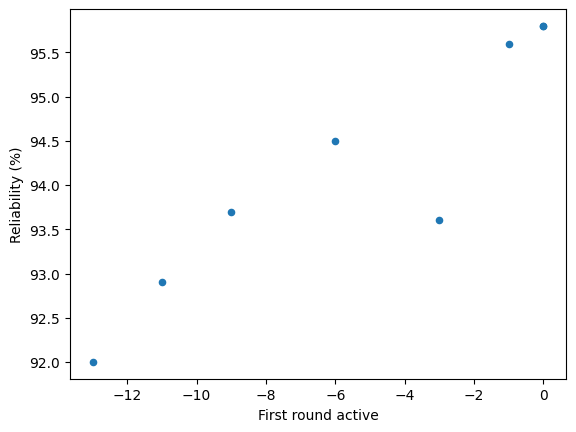

In [33]:
dispatch.plot.scatter(y='Reliability (%)', x='First round active')